# 03 — Topic Summary (8-Topic Model)

Topic identification from the 8-topic LDA model (`output/lda_vis_chn_8.html`).

Topics are identified using pyLDAvis display ordering with loglift-ranked terms to cut through
boilerplate and surface substantive case-content signals. The pie chart uses two nested outer
category arcs: an inner arc for sub-clusters and an outer arc for main dispute categories.

## 1. Imports & Chinese Font Setup

In [87]:
import json, re
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm

_cjk = ['PingFang SC', 'Heiti SC', 'STHeiti', 'SimHei', 'Noto Sans CJK SC']
_avail = {f.name for f in fm.fontManager.ttflist}
_font = next((f for f in _cjk if f in _avail), None)
if _font:
    matplotlib.rcParams['font.family'] = _font
    print(f'Using CJK font: {_font}')
else:
    print('No CJK font found — Chinese labels may render as boxes')
matplotlib.rcParams['axes.unicode_minus'] = False

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

Using CJK font: STHeiti


## 2. Parse `lda_vis_chn_8.html`

In [88]:
with open("../output/lda_vis_chn_8.html") as f:
    html = f.read()

match = re.search(r'var ldavis_\w+_data = ({.*?});', html, re.DOTALL)
lda_data = json.loads(match.group(1))
tinfo    = lda_data["tinfo"]
mds      = lda_data["mdsDat"]

print("topic.order (display -> gensim 1-indexed):", lda_data["topic.order"])
print("\nDisplay topic corpus shares:")
for t, f in zip(mds["topics"], mds["Freq"]):
    print(f"  Display Topic {t}: {f:.2f}%")

topic.order (display -> gensim 1-indexed): [5, 4, 8, 3, 1, 6, 2, 7]

Display topic corpus shares:
  Display Topic 1: 21.94%
  Display Topic 2: 21.67%
  Display Topic 3: 16.27%
  Display Topic 4: 13.63%
  Display Topic 5: 9.53%
  Display Topic 6: 9.32%
  Display Topic 7: 4.29%
  Display Topic 8: 3.35%


In [89]:
# Extract top terms per display topic by loglift and frequency
topic_terms = {}
for tn in range(1, 9):
    cat = f"Topic{tn}"
    rows = [(tinfo["Term"][i], round(tinfo["Freq"][i], 2), round(tinfo["loglift"][i], 3))
            for i, c in enumerate(tinfo["Category"]) if c == cat]
    topic_terms[tn] = {
        "loglift": [t for t, f, l in sorted(rows, key=lambda x: -x[2])[:12]],
        "freq":    [t for t, f, l in sorted(rows, key=lambda x: -x[1])[:10]],
    }

for tn in range(1, 9):
    print(f"Display Topic {tn}")
    print(f"  loglift: {topic_terms[tn]['loglift']}")
    print(f"  freq:    {topic_terms[tn]['freq']}")
    print()

Display Topic 1
  loglift: ['在编', '年利率', '欠款', '借款人', '清偿', '违纪', '处理意见', '体委', '离队', '佐证', '服从组织', '京民']
  freq:    ['体育局', '民事判决', '择业', '人事处', '人事厅', '运动队', '体委', '工资待遇', '离队', '退役费']

Display Topic 2
  loglift: ['公司财务', '补救措施', '经手人', '强强', '补充协议', '兽药', '观光旅游', '公德', '出库', '蔬菜水果', '公猪', '做强']
  freq:    ['履行合同', '公司财务', '补救措施', '借条', '出借', '下属单位', '转款', '授权书', '欠付', '公章']

Display Topic 3
  loglift: ['住宿费', '小学文化', '碑林区', '豪犯', '文文', '麟游', '法律效力', '外事学院', '椎间盘', '工作队', '民事', '食宿费']
  freq:    ['民事裁定', '民事', '退役', '运动员', '体育局', '补偿金', '体工队', '民事判决', '补发', '住宿费']

Display Topic 4
  loglift: ['工伤保险', '书面通知', '共融', '存档', '月入', '赔偿金', '工作大队', '停缴', '合同法', '补助金', '伤病', '报请']
  freq:    ['补偿费', '聘用', '择业', '体育局', '停发', '赔偿金', '工伤保险', '国家体育总局', '伤病', '辞退']

Display Topic 5
  loglift: ['财产损失', '肖像权', '百科', '致歉', '文末', '二维码', '版面', '侵权行为', '截图', '责任法', '微信', '赔偿损失']
  freq:    ['微信', '截图', '抚慰金', '财产损失', '赔偿损失', '肖像权', '百科', '致歉', '文末', '二维码']

Display Topic 6
  loglift: ['行政诉讼法', '体工', '起诉

## 3. Topic Identification

The 8-topic model (`lda_vis_chn_8.html`) splits the five original topics into finer sub-themes.
Identification uses **loglift** (exclusivity) over frequency to avoid boilerplate inflation.

The 8 topics fall into three sports sub-clusters and one commercial cluster. T5 (Online Infringement
& Image-Rights) is grouped under **Commercial / Financial** because these cases centre on the
unauthorised commercial exploitation of athlete likeness for profit.

| Display T | Corpus % | Gensim idx | Top loglift terms | Sub-cluster |
|---|---|---|---|---|
| T1 | 21.9% | 5 | 在编, 欠款, 违纪, 体委, 离队 | Personnel & Admin |
| T2 | 21.7% | 4 | 公司财务, 补救措施, 兽药, 经手人 | Commercial |
| T3 | 16.3% | 8 | 住宿费, 椎间盘, 工作队, 食宿费 | Medical & Injury |
| T4 | 13.6% | 3 | 工伤保险, 书面通知, 赔偿金, 伤病 | Medical & Injury |
| T5 | 9.5%  | 1 | 财产损失, 肖像权, 百科, 致歉, 二维码 | Commercial (image-rights exploitation) |
| T6 | 9.3%  | 6 | 行政诉讼法, 体工, 起诉状, 函号 | Personnel & Admin |
| T7 | 4.3%  | 2 | 体育运动, 木樨园, 工龄, 社会保险, 半月板 | Medical & Injury |
| T8 | 3.4%  | 7 | 时效, 垒球, 全运会, 扣发, 主体资格 | Personnel & Admin |

T1's high-loglift debt terms (年利率, 欠款, 清偿) reflect back-pay settlement language embedded
in formal HR decisions — the frequency terms (择业, 工资待遇, 体委) confirm a sports-HR topic.

In [90]:
# topic.order: [5, 4, 8, 3, 1, 6, 2, 7]
# Display T1 = Gensim 5  (Python idx 4)
# Display T2 = Gensim 4  (Python idx 3)
# Display T3 = Gensim 8  (Python idx 7)
# Display T4 = Gensim 3  (Python idx 2)
# Display T5 = Gensim 1  (Python idx 0)
# Display T6 = Gensim 6  (Python idx 5)
# Display T7 = Gensim 2  (Python idx 1)
# Display T8 = Gensim 7  (Python idx 6)

TOPIC_META = {
    1: {
        "zh": "运动队编制管理与工资薪酬",
        "en": "Sports-Team Roster Management & Wage Disputes",
        "pct": 21.94,
        "gensim_idx": 4,
        "cluster": "sports",
        "sub_cluster": "personnel",
        "top_terms_ll": ["在编","年利率","欠款","借款人","清偿","违纪","处理意见","体委","离队","佐证","服从组织"],
        "top_terms_fr": ["体育局","民事判决","择业","人事处","人事厅","运动队","体委","工资待遇","离队","退役费"],
        "description": (
            "Core sports HR disputes (21.9%). Roster status (在编), disciplinary proceedings "
            "(违纪), departure from team (离队), and wage recovery — primarily against sports "
            "bureaus (体育局, 体委) and personnel departments (人事处/人事厅). High-loglift "
            "debt terms (年利率, 欠款, 清偿) reflect back-pay settlement language embedded "
            "in formal HR decisions."
        ),
    },
    2: {
        "zh": "商业合同违约与债务追偿",
        "en": "Commercial Contract Breach & Debt Recovery",
        "pct": 21.67,
        "gensim_idx": 3,
        "cluster": "commercial",
        "sub_cluster": "commercial",
        "top_terms_ll": ["公司财务","补救措施","经手人","强强","补充协议","兽药","观光旅游","公德","出库","蔬菜水果"],
        "top_terms_fr": ["履行合同","公司财务","补救措施","借条","出借","下属单位","转款","授权书","欠付","公章"],
        "description": (
            "Commercial and financial disputes (21.7%). Sports organizations as parties to "
            "supply, service, or loan contracts. Highly distinctive vocabulary: supplementary "
            "agreements (补充协议), contract handlers (经手人), and industry-specific goods "
            "(兽药 veterinary drugs, 蔬菜水果 produce) confirm sports-club commercial "
            "operations. Consistent across all model sizes."
        ),
    },
    3: {
        "zh": "一般运动员赔偿与医疗费用",
        "en": "General Athlete Compensation & Medical Costs",
        "pct": 16.27,
        "gensim_idx": 7,
        "cluster": "sports",
        "sub_cluster": "medical",
        "top_terms_ll": ["住宿费","椎间盘","工作队","食宿费","法律效力","小学文化","外事学院","碑林区"],
        "top_terms_fr": ["民事裁定","民事","退役","运动员","体育局","补偿金","体工队","民事判决","补发","住宿费"],
        "description": (
            "Catch-all compensation topic (16.3%). Combines medical/injury line items "
            "(住宿费, 椎间盘, 食宿费) with general retirement-and-compensation boilerplate "
            "(民事裁定, 退役, 补偿金, 体工队). Distinctive loglift terms include specific "
            "locality names (碑林区) and contextual markers (小学文化, 外事学院) that anchor "
            "individual case narratives."
        ),
    },
    4: {
        "zh": "工伤保险与劳动合同解除纠纷",
        "en": "Work Injury Insurance & Employment Termination",
        "pct": 13.63,
        "gensim_idx": 2,
        "cluster": "sports",
        "sub_cluster": "medical",
        "top_terms_ll": ["工伤保险","书面通知","共融","存档","月入","赔偿金","工作大队","停缴","合同法","补助金","伤病"],
        "top_terms_fr": ["补偿费","聘用","择业","体育局","停发","赔偿金","工伤保险","国家体育总局","伤病","辞退"],
        "description": (
            "Insurance and dismissal cases (13.6%). Distinct from purely medical topics by "
            "emphasis on work injury insurance (工伤保险), employment contracts (合同法), "
            "and formal termination procedures (辞退, 停发, 书面通知). Athletes claim "
            "compensation for sports-related illness/injury (伤病) combined with wrongful "
            "or uncompensated dismissal from sports units."
        ),
    },
    5: {
        "zh": "网络侵权与运动员肖像权",
        "en": "Online Infringement & Athlete Image-Rights",
        "pct": 9.53,
        "gensim_idx": 0,
        "cluster": "commercial",
        "sub_cluster": "rights",
        "top_terms_ll": ["财产损失","肖像权","百科","致歉","文末","二维码","版面","侵权行为","截图","责任法","微信"],
        "top_terms_fr": ["微信","截图","抚慰金","财产损失","赔偿损失","肖像权","百科","致歉","文末","二维码"],
        "description": (
            "Digital image-rights exploitation (9.5%). Unauthorized commercial use of "
            "athlete likeness via WeChat (微信), QR codes (二维码), screenshots (截图), and "
            "online encyclopedia edits (百科). Plaintiffs seek apologies (致歉) and "
            "compensation for property and dignity losses (财产损失, 抚慰金). Grouped under "
            "Commercial / Financial at the top level because the core dispute is monetisation "
            "of athlete identity without consent; legally grounded in 责任法 (Tort Liability Law)."
        ),
    },
    6: {
        "zh": "行政诉讼程序与形式要件",
        "en": "Administrative Litigation Procedure & Formal Requirements",
        "pct": 9.32,
        "gensim_idx": 5,
        "cluster": "sports",
        "sub_cluster": "personnel",
        "top_terms_ll": ["行政诉讼法","体工","起诉状","签收","三性","加盖","刑诉","函号","写明","意见书","发号"],
        "top_terms_fr": ["行政诉讼法","体育局","补发","体工","起诉状","签收","原系","三性","刑诉","函号"],
        "description": (
            "Administrative litigation formalities (9.3%). Cases focusing on procedural "
            "requirements under administrative litigation law (行政诉讼法): proper service "
            "(签收), official letter numbers (函号/发号), stamping requirements (加盖), "
            "written complaints (起诉状/意见书), and the three-pronged admissibility test "
            "(三性). Sports-unit standing (体工, 主体资格) is a central contested issue."
        ),
    },
    7: {
        "zh": "体育训练伤害与社会保险",
        "en": "Sports Training Injuries & Social Insurance",
        "pct": 4.29,
        "gensim_idx": 1,
        "cluster": "sports",
        "sub_cluster": "medical",
        "top_terms_ll": ["体育运动","木樨园","受理","工龄","纠纷案件","代表人","体育训练","社会保险","半月板","适用"],
        "top_terms_fr": ["体育运动","木樨园","受理","工龄","体育训练","运动员","民事","退役","纠纷案件","社会保险"],
        "description": (
            "Sports training injury and pension cases (4.3%). Injuries arising during "
            "organised training (体育训练) or competition, intersecting with social insurance "
            "and seniority (工龄) entitlements. Injury marker: 半月板 (meniscus tear). "
            "Location marker 木樨园 (Beijing's Muxiyuan Sports Complex) anchors a cluster "
            "of specific cases."
        ),
    },
    8: {
        "zh": "诉讼时效与退役安置争议",
        "en": "Statute of Limitations & Retirement Placement Disputes",
        "pct": 3.35,
        "gensim_idx": 6,
        "cluster": "sports",
        "sub_cluster": "personnel",
        "top_terms_ll": ["经省","时效","垒球","打球","全运会","扣发","当庭","因私","另案"],
        "top_terms_fr": ["体工队","经省","时效","停发","书面形式","体育局","择业","人事局","报请","主体资格"],
        "description": (
            "Procedural time-bar and retirement disputes (3.4%). Smallest topic; "
            "centres on statute-of-limitations (时效) challenges raised by defendants "
            "in retirement-placement cases. Sport markers (垒球 softball, 打球 ball play, "
            "全运会 National Games) confirm athlete context. Procedural overlap with T6 "
            "on standing (主体资格)."
        ),
    },
}

for tn, m in TOPIC_META.items():
    print(f"Display T{tn} ({m['pct']}%)  [cluster={m['cluster']}, sub={m['sub_cluster']}]")
    print(f"  ZH: {m['zh']}")
    print(f"  EN: {m['en']}")
    print(f"  Key (loglift): {', '.join(m['top_terms_ll'][:5])}")
    print()

Display T1 (21.94%)  [cluster=sports, sub=personnel]
  ZH: 运动队编制管理与工资薪酬
  EN: Sports-Team Roster Management & Wage Disputes
  Key (loglift): 在编, 年利率, 欠款, 借款人, 清偿

Display T2 (21.67%)  [cluster=commercial, sub=commercial]
  ZH: 商业合同违约与债务追偿
  EN: Commercial Contract Breach & Debt Recovery
  Key (loglift): 公司财务, 补救措施, 经手人, 强强, 补充协议

Display T3 (16.27%)  [cluster=sports, sub=medical]
  ZH: 一般运动员赔偿与医疗费用
  EN: General Athlete Compensation & Medical Costs
  Key (loglift): 住宿费, 椎间盘, 工作队, 食宿费, 法律效力

Display T4 (13.63%)  [cluster=sports, sub=medical]
  ZH: 工伤保险与劳动合同解除纠纷
  EN: Work Injury Insurance & Employment Termination
  Key (loglift): 工伤保险, 书面通知, 共融, 存档, 月入

Display T5 (9.53%)  [cluster=commercial, sub=rights]
  ZH: 网络侵权与运动员肖像权
  EN: Online Infringement & Athlete Image-Rights
  Key (loglift): 财产损失, 肖像权, 百科, 致歉, 文末

Display T6 (9.32%)  [cluster=sports, sub=personnel]
  ZH: 行政诉讼程序与形式要件
  EN: Administrative Litigation Procedure & Formal Requirements
  Key (loglift): 行政诉讼法, 体工, 起诉状, 签收, 三性

Disp

## 4. Summary Table

In [91]:
SUB_LABEL = {
    "personnel": "Sports — Personnel & Admin",
    "medical":   "Sports — Medical & Injury",
    "rights":    "Commercial — Image Rights",
    "commercial": "Commercial / Financial",
}

rows = []
for tn, m in TOPIC_META.items():
    rows.append({
        "Display T": f"T{tn}",
        "Corpus %": f"{m['pct']:.1f}%",
        "Sub-cluster": SUB_LABEL[m["sub_cluster"]],
        "Topic (CHN)": m["zh"],
        "Top Terms (loglift)": ", ".join(m["top_terms_ll"][:5]),
        "Topic (EN)": m["en"],
    })

summary = pd.DataFrame(rows).set_index("Display T")
pd.set_option("display.max_colwidth", 55)
summary

,Corpus %,Sub-cluster,Topic (CHN),Top Terms (loglift),Topic (EN)
Display T,,,,,
T1,21.9%,Sports — Personnel & Admin,运动队编制管理与工资薪酬,"在编, 年利率, 欠款, 借款人, 清偿",Sports-Team Roster Management & Wage Disputes
T2,21.7%,Commercial / Financial,商业合同违约与债务追偿,"公司财务, 补救措施, 经手人, 强强, 补充协议",Commercial Contract Breach & Debt Recovery
T3,16.3%,Sports — Medical & Injury,一般运动员赔偿与医疗费用,"住宿费, 椎间盘, 工作队, 食宿费, 法律效力",General Athlete Compensation & Medical Costs
T4,13.6%,Sports — Medical & Injury,工伤保险与劳动合同解除纠纷,"工伤保险, 书面通知, 共融, 存档, 月入",Work Injury Insurance & Employment Termination
T5,9.5%,Commercial — Image Rights,网络侵权与运动员肖像权,"财产损失, 肖像权, 百科, 致歉, 文末",Online Infringement & Athlete Image-Rights
T6,9.3%,Sports — Personnel & Admin,行政诉讼程序与形式要件,"行政诉讼法, 体工, 起诉状, 签收, 三性",Administrative Litigation Procedure & Formal Requir...
T7,4.3%,Sports — Medical & Injury,体育训练伤害与社会保险,"体育运动, 木樨园, 受理, 工龄, 纠纷案件",Sports Training Injuries & Social Insurance
T8,3.4%,Sports — Personnel & Admin,诉讼时效与退役安置争议,"经省, 时效, 垒球, 打球, 全运会",Statute of Limitations & Retirement Placement Disputes


In [97]:
summaryTable = summary[["Corpus %", "Topic (EN)", "Topic (CHN)", 'Top Terms (loglift)']]
summaryTable
# summaryTable["Corpus %"] = summaryTable["Corpus"].apply(lambda x: f"{x:.1f}%")
# summaryTable[["Corpus %", "Topic (EN)", "Topic (CHN)", 'Top Terms (loglift)']]

,Corpus %,Topic (EN),Topic (CHN),Top Terms (loglift)
Display T,,,,
T1,21.9%,Sports-Team Roster Management & Wage Disputes,运动队编制管理与工资薪酬,"在编, 年利率, 欠款, 借款人, 清偿"
T2,21.7%,Commercial Contract Breach & Debt Recovery,商业合同违约与债务追偿,"公司财务, 补救措施, 经手人, 强强, 补充协议"
T3,16.3%,General Athlete Compensation & Medical Costs,一般运动员赔偿与医疗费用,"住宿费, 椎间盘, 工作队, 食宿费, 法律效力"
T4,13.6%,Work Injury Insurance & Employment Termination,工伤保险与劳动合同解除纠纷,"工伤保险, 书面通知, 共融, 存档, 月入"
T5,9.5%,Online Infringement & Athlete Image-Rights,网络侵权与运动员肖像权,"财产损失, 肖像权, 百科, 致歉, 文末"
T6,9.3%,Administrative Litigation Procedure & Formal Requir...,行政诉讼程序与形式要件,"行政诉讼法, 体工, 起诉状, 签收, 三性"
T7,4.3%,Sports Training Injuries & Social Insurance,体育训练伤害与社会保险,"体育运动, 木樨园, 受理, 工龄, 纠纷案件"
T8,3.4%,Statute of Limitations & Retirement Placement Disputes,诉讼时效与退役安置争议,"经省, 时效, 垒球, 打球, 全运会"


## 5. Nested Cluster Breakdown

In [93]:
sports_pct = sum(m["pct"] for m in TOPIC_META.values() if m["cluster"] == "sports")
comm_pct   = sum(m["pct"] for m in TOPIC_META.values() if m["cluster"] == "commercial")

sub_sums = {}
for m in TOPIC_META.values():
    sub_sums[m["sub_cluster"]] = sub_sums.get(m["sub_cluster"], 0) + m["pct"]

personnel_topics = [f"T{t}" for t, m in TOPIC_META.items() if m["sub_cluster"]=="personnel"]
medical_topics   = [f"T{t}" for t, m in TOPIC_META.items() if m["sub_cluster"]=="medical"]
comm_topics      = [f"T{t}" for t, m in TOPIC_META.items() if m["cluster"]=="commercial"]

print("Nested cluster shares (8-topic model):")
print(f"  Sports-Specific Disputes  : {sports_pct:.1f}%")
print(f"    ↳ Personnel & Admin     : {sub_sums['personnel']:.1f}%  ({', '.join(personnel_topics)})")
print(f"    ↳ Medical & Injury      : {sub_sums['medical']:.1f}%  ({', '.join(medical_topics)})")
print(f"  Commercial / Financial    : {comm_pct:.1f}%  ({', '.join(comm_topics)})")
print(f"    ↳ Contract & Debt       : {TOPIC_META[2]['pct']:.1f}%  (T2)")
print(f"    ↳ Image-Rights Exploit. : {TOPIC_META[5]['pct']:.1f}%  (T5)")
print(f"  Total                     : {sports_pct+comm_pct:.1f}%")

Nested cluster shares (8-topic model):
  Sports-Specific Disputes  : 68.8%
    ↳ Personnel & Admin     : 34.6%  (T1, T6, T8)
    ↳ Medical & Injury      : 34.2%  (T3, T4, T7)
  Commercial / Financial    : 31.2%  (T2, T5)
    ↳ Contract & Debt       : 21.7%  (T2)
    ↳ Image-Rights Exploit. : 9.5%  (T5)
  Total                     : 100.0%


## 6. Topic Distribution Pie Chart with Nested Arcs

Topics are grouped and ordered by cluster: Personnel & Admin (T1, T6, T8) → Medical & Injury
(T3, T4, T7) → Commercial (T2, T5). Two outer arc layers show the nested category structure:
- **Inner arc** (Layer 1): three sub-clusters within sports + commercial (which contains T2 and T5)
- **Outer arc** (Layer 2): two main clusters (Sports vs Commercial)

Text(0, 0, 'Athlete\nCourt Cases\n(n = 79)')

/var/folders/9c/c84wrldd0wgbdtr9v0n9gp100000gn/T/ipykernel_9282/2613024679.py:68: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(mpatches.Wedge(


/var/folders/9c/c84wrldd0wgbdtr9v0n9gp100000gn/T/ipykernel_9282/2613024679.py:83: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(mpatches.Wedge(


/var/folders/9c/c84wrldd0wgbdtr9v0n9gp100000gn/T/ipykernel_9282/2613024679.py:87: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(mpatches.Wedge(


Text(-1.1067217588424683, 0.5810911655426025, 'Personnel\n& Admin')

...

Text(1.7027212381362915, 1.141595482826233, 'Commercial &\nFinancial (31.2%)')

(-2.4, 2.4)

(-2.5, 2.4)

(np.float64(-2.4), np.float64(2.4), np.float64(-2.5), np.float64(2.4))

Text(0.5, 1.0, 'LDA Topic Distribution — Athlete Court Cases\n(inner arc = sub-cluster; outer arc = main cluster; slice area ∝ corpus share)')

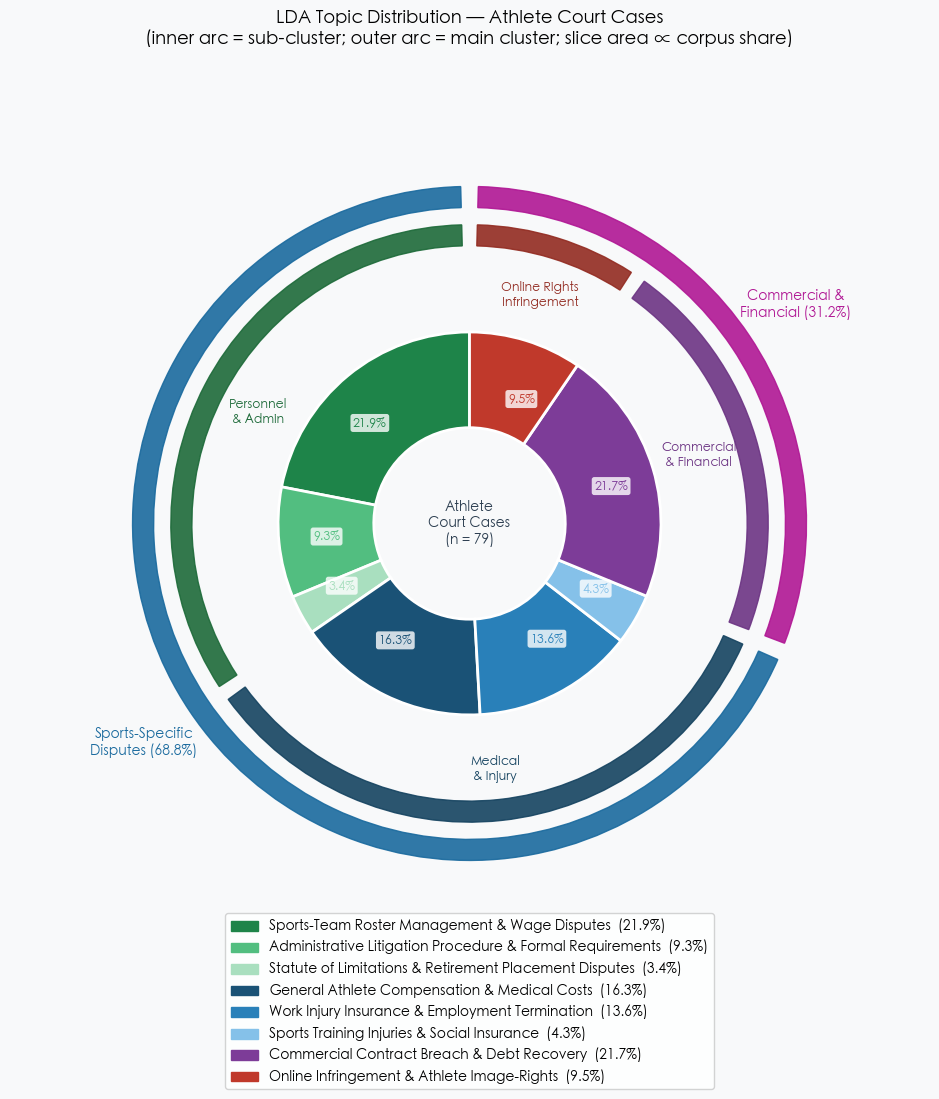

Saved -> ../output/topic_pie_n8.png


In [99]:
# ── Colors ──────────────────────────────────────────────────────────────────
# Personnel group: greens; Medical group: blues; Rights: red; Commercial: purple
COLORS = {
    1: "#1E8449",   # dark green    — roster/wages
    2: "#7D3C98",   # purple        — commercial contract
    3: "#1A5276",   # dark blue     — general compensation
    4: "#2980B9",   # medium blue   — work injury insurance
    5: "#C0392B",   # red           — image rights
    6: "#52BE80",   # medium green  — admin litigation
    7: "#85C1E9",   # light blue    — training injury
    8: "#A9DFBF",   # pale green    — statute of limitations
}

# Sub-cluster arc colors (Layer 1)
SUBCL_COLORS = {
    "personnel": "#1D6A39",   # deep green
    "medical":   "#154360",   # deep blue
    "rights":    "#922B21",   # deep red
    "commercial": "#6C3483",  # deep purple
}

# Main cluster arc colors (Layer 2)
SPORTS_COLOR = "#1A6A9E"
COMM_COLOR   = "#b01794"

# ── Pie ordering: Personnel (T1,T6,T8) | Medical (T3,T4,T7) | Commercial (T2,T5) ──
# wedge indices:     0, 1, 2            |  3, 4, 5           |  6, 7
topic_order  = [1, 6, 8, 3, 4, 7, 2, 5]
pcts         = [TOPIC_META[t]["pct"] for t in topic_order]
wedge_labels = [f"{TOPIC_META[t]['pct']:.1f}%" for t in topic_order]

fig, ax = plt.subplots(figsize=(12, 11))
ax.set_aspect("equal")
ax.set_facecolor("#f8f9fa")
fig.patch.set_facecolor("#f8f9fa")

wedges, texts = ax.pie(
    pcts,
    labels=wedge_labels,
    colors=[COLORS[t] for t in topic_order],
    startangle=90,
    labeldistance=0.68,
    wedgeprops=dict(edgecolor="white", linewidth=2.0, width=0.50),
    textprops=dict(fontsize=9.0, fontweight="bold",
                   bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8)),
)
for text, tn in zip(texts, topic_order):
    text.set_color(COLORS[tn])

ax.text(0, 0, "Athlete\nCourt Cases\n(n = 79)",
        ha="center", va="center", fontsize=10,
        fontweight="bold", color="#2C3E50")

# ── Layer 1: sub-cluster arcs (inner) ───────────────────────────────────────
# T5 keeps its own "rights" arc; T2 keeps its own "commercial" arc
ARC1_INNER, ARC1_OUTER, GAP1 = 1.45, 1.56, 1.5

sub_groups = [
    ("personnel", 0, 2),   # T1, T6, T8 → wedges 0–2
    ("medical",   3, 5),   # T3, T4, T7 → wedges 3–5
    ("commercial",6, 6),   # T2         → wedge  6
    ("rights",    7, 7),   # T5         → wedge  7
]

for sub, start_idx, end_idx in sub_groups:
    t1 = wedges[start_idx].theta1
    t2 = wedges[end_idx].theta2
    ax.add_patch(mpatches.Wedge(
        (0, 0), ARC1_OUTER, t1 + GAP1, t2 - GAP1,
        width=ARC1_OUTER - ARC1_INNER,
        color=SUBCL_COLORS[sub], alpha=0.90, edgecolor="none",
    ))

# ── Layer 2: main cluster arcs (outer) ──────────────────────────────────────
# Sports = wedges 0–5 (T1,T6,T8,T3,T4,T7); Commercial = wedges 6–7 (T2,T5)
ARC2_INNER, ARC2_OUTER, GAP2 = 1.65, 1.76, 1.5

sports_t1 = wedges[0].theta1
sports_t2 = wedges[5].theta2
comm_t1   = wedges[6].theta1
comm_t2   = wedges[7].theta2

ax.add_patch(mpatches.Wedge(
    (0, 0), ARC2_OUTER, sports_t1 + GAP2, sports_t2 - GAP2,
    width=ARC2_OUTER - ARC2_INNER, color=SPORTS_COLOR, alpha=0.90, edgecolor="none",
))
ax.add_patch(mpatches.Wedge(
    (0, 0), ARC2_OUTER, comm_t1 + GAP2, comm_t2 - GAP2,
    width=ARC2_OUTER - ARC2_INNER, color=COMM_COLOR, alpha=0.90, edgecolor="none",
))

# ── Arc labels ────────────────────────────────────────────────────────────────
L1_LABEL_R = 1.25
SUB_LABELS = {
    "personnel": "Personnel\n& Admin",
    "medical":   "\nMedical\n& Injury",
    "commercial": "Commercial\n& Financial",
    "rights":    "Online Rights\nInfringement",
}
for sub, start_idx, end_idx in sub_groups:
    t1 = wedges[start_idx].theta1
    t2 = wedges[end_idx].theta2
    mid = np.radians((t1 + t2) / 2)
    ax.text(L1_LABEL_R * np.cos(mid), L1_LABEL_R * np.sin(mid),
            SUB_LABELS[sub],
            ha="center", va="center", fontsize=9,
            fontweight="bold", color=SUBCL_COLORS[sub])

L2_LABEL_R = 2.05
sports_mid = np.radians((sports_t1 + sports_t2) / 2)
comm_mid   = np.radians((comm_t1   + comm_t2)   / 2)

ax.text(L2_LABEL_R * np.cos(sports_mid), L2_LABEL_R * np.sin(sports_mid),
        "Sports-Specific\nDisputes (68.8%)",
        ha="center", va="center", fontsize=10, fontweight="bold", color=SPORTS_COLOR)
ax.text(L2_LABEL_R * np.cos(comm_mid), L2_LABEL_R * np.sin(comm_mid),
        "Commercial &\nFinancial (31.2%)",
        ha="center", va="center", fontsize=10, fontweight="bold", color=COMM_COLOR)

ax.set_xlim(-2.4, 2.4)
ax.set_ylim(-2.5, 2.4)
ax.axis("off")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    mpatches.Patch(color=COLORS[1], label="Sports-Team Roster Management & Wage Disputes  (21.9%)"),
    mpatches.Patch(color=COLORS[6], label="Administrative Litigation Procedure & Formal Requirements  (9.3%)"),
    mpatches.Patch(color=COLORS[8], label="Statute of Limitations & Retirement Placement Disputes  (3.4%)"),
    mpatches.Patch(color=COLORS[3], label="General Athlete Compensation & Medical Costs  (16.3%)"),
    mpatches.Patch(color=COLORS[4], label="Work Injury Insurance & Employment Termination  (13.6%)"),
    mpatches.Patch(color=COLORS[7], label="Sports Training Injuries & Social Insurance  (4.3%)"),
    mpatches.Patch(color=COLORS[2], label="Commercial Contract Breach & Debt Recovery  (21.7%)"),
    mpatches.Patch(color=COLORS[5], label="Online Infringement & Athlete Image-Rights  (9.5%)"),
]
ax.legend(handles=legend_handles, loc="lower center", ncol=1,
          fontsize=10, framealpha=0.85, edgecolor="#ccc",
          bbox_to_anchor=(0.5, -0.1))

ax.set_title(
    "LDA Topic Distribution — Athlete Court Cases\n"
    "(inner arc = sub-cluster; outer arc = main cluster; slice area ∝ corpus share)",
    fontsize=13, fontweight="bold", pad=14,
)

plt.tight_layout()
plt.savefig("../output/topic_pie_n8.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> ../output/topic_pie_n8.png")